In [ ]:
!unzip emron.zip

Archive:  emron.zip
   creating: data/
  inflating: data/enron_flagged_emails.json  
  inflating: data/enron_model.jsonl  
  inflating: __MACOSX/data/._enron_model.jsonl  
  inflating: data/emros_curpose.json  
  inflating: data/report_flagged.csv  
  inflating: data/enron_scored_emails.csv  
  inflating: data/summary_stat_keyword_filters2.csv  
  inflating: data/enron_scored_emails2.csv  
  inflating: __MACOSX/data/._enron_scored_emails2.csv  
  inflating: data/report_flagged.json  
  inflating: data/enron_top52.json   
  inflating: data/report_all_scored.csv  
  inflating: data/enron_flagged_emails2.json  
  inflating: __MACOSX/data/._enron_flagged_emails2.json  
  inflating: data/enron_prediction.jsonl  
  inflating: data/full_keyword_filter_stat2.csv  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

  - enron_scored_emails.csv (25MB) — all LLM-scored emails with per-question scores
  - enron_flagged_emails.json (4.8MB) — all SUSPICIOUS+ emails with full details


In [ ]:
import pandas as pd
import json
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


emros_curpose.json          enron_top52.json
enron_flagged_emails2.json  full_keyword_filter_stat2.csv
enron_flagged_emails.json   report_all_scored.csv
enron_model.jsonl           report_flagged.csv
enron_prediction.jsonl      report_flagged.json
enron_scored_emails2.csv    summary_stat_keyword_filters2.csv
enron_scored_emails.csv


# Flagged Email

In [ ]:
with open("data/enron_flagged_emails.json", 'r') as file:
        enron_flagged_emails = json.load(file)
df_flagged_all = pd.DataFrame(enron_flagged_emails)
df_flagged_all['date'] = pd.to_datetime(df_flagged_all['date'])


df = pd.read_csv('data/report_flagged.csv')
df['date'] = pd.to_datetime(df['date'])

df["id"] = df["id"].astype(int)
df_flagged_all["id"] = df_flagged_all["id"].astype(int)

df_spam = df_flagged_all[~df_flagged_all['id'].isin(df['id'])]

High_threshold = 18
df["m_flaged"] = df["llm_total"].apply(lambda x: "HIGH" if x >= High_threshold else "Suspicious")




In [ ]:
print(f"Number of total LLM FLAGED (HIGH or suspecision): {len(df_flagged_all)}")
print(f"Number of Spam Emails (not related ): {len(df)}")
print(f"Number of Spam emails: {len(df_spam)}")

number_high = len(df[df["m_flaged"] == "HIGH"])
print(f"Number of HIGH score emails is {number_high}.")
print(f"Threhold of Suspicious email: {df.llm_total.min()}")
print(  f"Threhold of Flgged High  email: {High_threshold}")
print(f"Perecntage of HIGH score emails vs (suspicisus or HIGH) emails (after removing spams){round(number_high / len(df),4)}.")
print("So emails flagged as High are top 10% ")


Number of total LLM FLAGED (HIGH or suspecision): 647
Number of Spam Emails (not related ): 553
Number of Spam emails: 94
Number of HIGH score emails is 76.
Threhold of Suspicious email: 12
Threhold of Flgged High  email: 17
Perecntage of HIGH score emails vs (suspicisus or HIGH) emails (after removing spams)0.1374.
So emails flagged as High are top 10% 


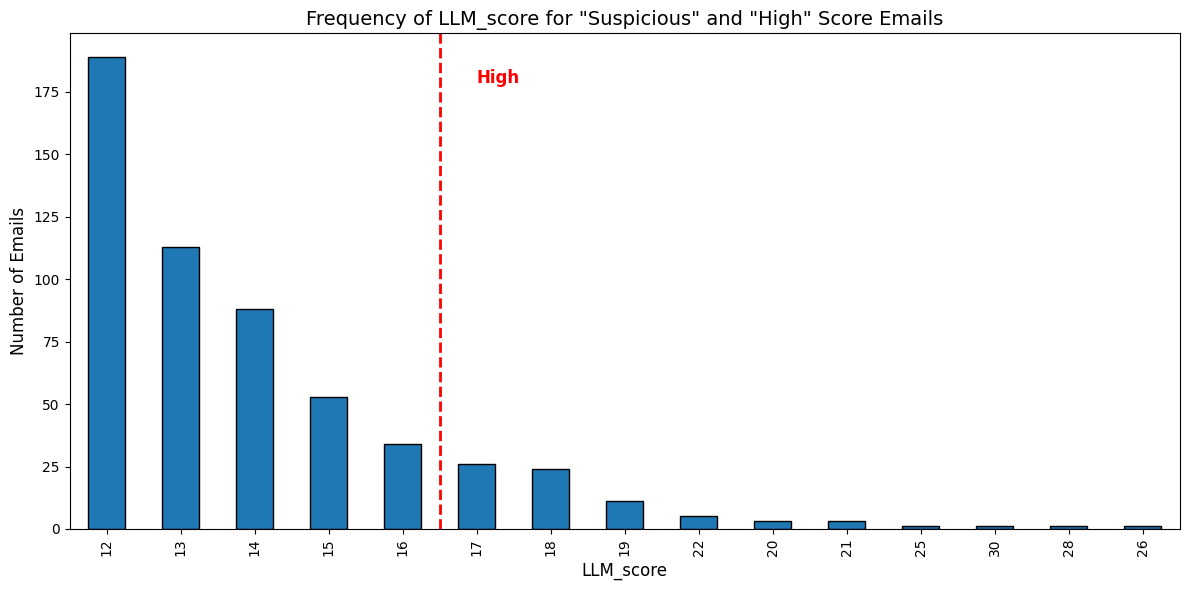

In [ ]:
df.llm_total.value_counts().plot.bar()

import matplotlib.pyplot as plt

ax = df.llm_total.value_counts().plot.bar(figsize=(12, 6), edgecolor='black')

plt.xlabel('LLM_score', fontsize=12)
plt.ylabel('Number of Emails', fontsize=12)
plt.title('Frequency of LLM_score for "Suspicious" and "High" Score Emails', fontsize=14)

plt.axvline(x=High_threshold - 12.5 , color='red', linestyle='--', linewidth=2, label='High Threshold')

plt.text(High_threshold - 12, ax.get_ylim()[1] * 0.9, 'High', color='red', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### Example of Spam email:

In [ ]:
print(df_spam.iloc[0].body)

email : charlesnujoma@37.com

    ATTN

  I m an accountant with the South Africa department of
  minieral resources and Energy and I am also a member
  of the South Africa contract award and monitoring
  committee in the South Africa department of mineral
  resources and Energy.  I am also on a special
  diplomatic duty in the South Africa foreign office in
  the foreign land.

  Sometimes ago, a contract was awarded to a foreign
  firm in Japan by my committee.  This contract was over
  invoiced to the tune of US$25.5 million.  The over
  invoicing was a deal by my committee to benefit from
  the project.  We now desire to transfer this money,
  which is presently in a suspense account of the
  Central Bank of South Africa (CBSA) into any overseas
  account where we expect you to provide for us.

  For providing the account where we shall remit the
  money, you will be entitled to 30% of the money, 68%
  will be for myself and my partner, the remaining 2%
  would be set aside to sett

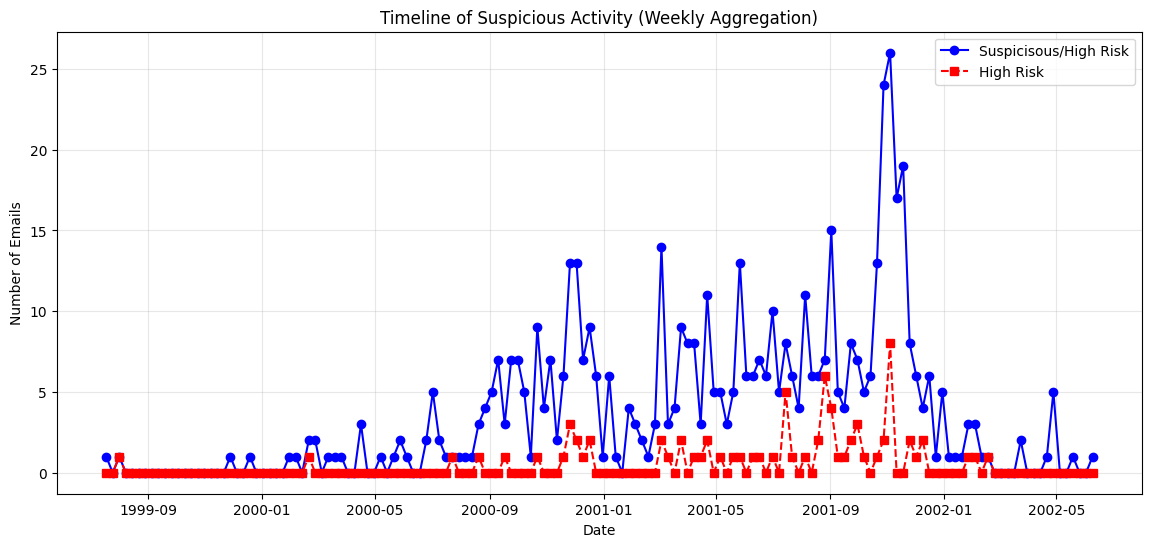


Peak Weeks for Suspicious Activity:


,date,count,high_count
0,2001-11-04,26.00,8.0
1,2001-10-28,24.00,2.0
2,2001-11-18,19.00,0.0
3,2001-11-11,17.00,0.0
4,2001-09-02,15.00,4.0
5,2001-03-04,14.00,2.0
6,2000-11-26,13.00,3.0
7,2000-12-03,13.00,2.0
8,2001-10-21,13.00,1.0
9,2001-05-27,13.00,1.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def get_timeline_chart(df):
    df['date'] = pd.to_datetime(df['date'])

    df_time = df.set_index('date').resample('W').size().reset_index(name='count')

    df_high = df[df['m_flaged'] == 'HIGH'].set_index('date').resample('W').size().reset_index(name='high_count')

    df_combined = pd.merge(df_time, df_high, on='date', how='left').fillna(0)

    plt.figure(figsize=(14, 6))

    plt.plot(df_combined['date'], df_combined['count'],
             marker='o', linestyle='-', color='b', label='Suspicisous/High Risk')

    plt.plot(df_combined['date'], df_combined['high_count'],
             marker='s', linestyle='--', color='r', label='High Risk')

    plt.title('Timeline of Suspicious Activity (Weekly Aggregation)')
    plt.xlabel('Date')
    plt.ylabel('Number of Emails')
    plt.legend() 
    plt.grid(True, alpha=0.3)
    plt.savefig('enron_timeline.png')
    plt.show()

    df_sorted = df_combined.sort_values(by='count', ascending=False)
    peak_weeks = df_sorted.head(10).copy()
    peak_weeks['date'] = peak_weeks['date'].dt.strftime('%Y-%m-%d')

    weeks_mean = df_sorted['count'].mean()
    mean_row = pd.DataFrame({
        'date': ['Mean for ALL Weeks'],
        'count': [round(weeks_mean, 2)],
        'high_count': [round(df_sorted['high_count'].mean(), 2)]
    })

    final_table = pd.concat([peak_weeks, mean_row], ignore_index=True)

    print("\nPeak Weeks for Suspicious Activity:")
    return final_table


get_timeline_chart(df)

Based on the analysis of the Enron dataset, the provided table highlights the weeks with the highest volume of suspicious email activity. This data suggests specific periods of intense communication that deviate significantly from the norm.

Key Findings from the Suspicious Activity Analysis
Extreme Statistical Deviations: The mean count for suspicious activity across all weeks is only 4.26. However, the peak week (2001-11-04) recorded 27.00 instances—nearly 6.3 times the average.

Concentrated Activity in Late 2001: There is a heavy cluster of suspicious activity between October and November 2001. Specifically, four out of the top six peak weeks occur consecutively or nearly consecutively in this window:

2001-10-28 (25.00)

2001-11-04 (27.00)

2001-11-11 (19.00)

2001-11-18 (19.00)

Also 2001-11-04 and 2001-09-02 are two weeks with highest risky emails. These two weeks also occur in same time window.  

Historical Context: These peaks align with critical moments in the Enron scandal. In October and November 2001, Enron disclosed massive losses, faced SEC investigations, and saw its stock price collapse, leading up to its eventual bankruptcy filing in December 2001.

Secondary Spikes: Other notable outliers occurred in May 2001 (20.00) and February 2002 (21.00), suggesting that suspicious communication was not limited to the final collapse but also appeared during earlier internal stresses and post-collapse investigations.

/tmp/ipykernel_1951/779315946.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='viridis', ax=ax1[0],
/tmp/ipykernel_1951/779315946.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='llm_total', palette='magma', ax=ax1[1])


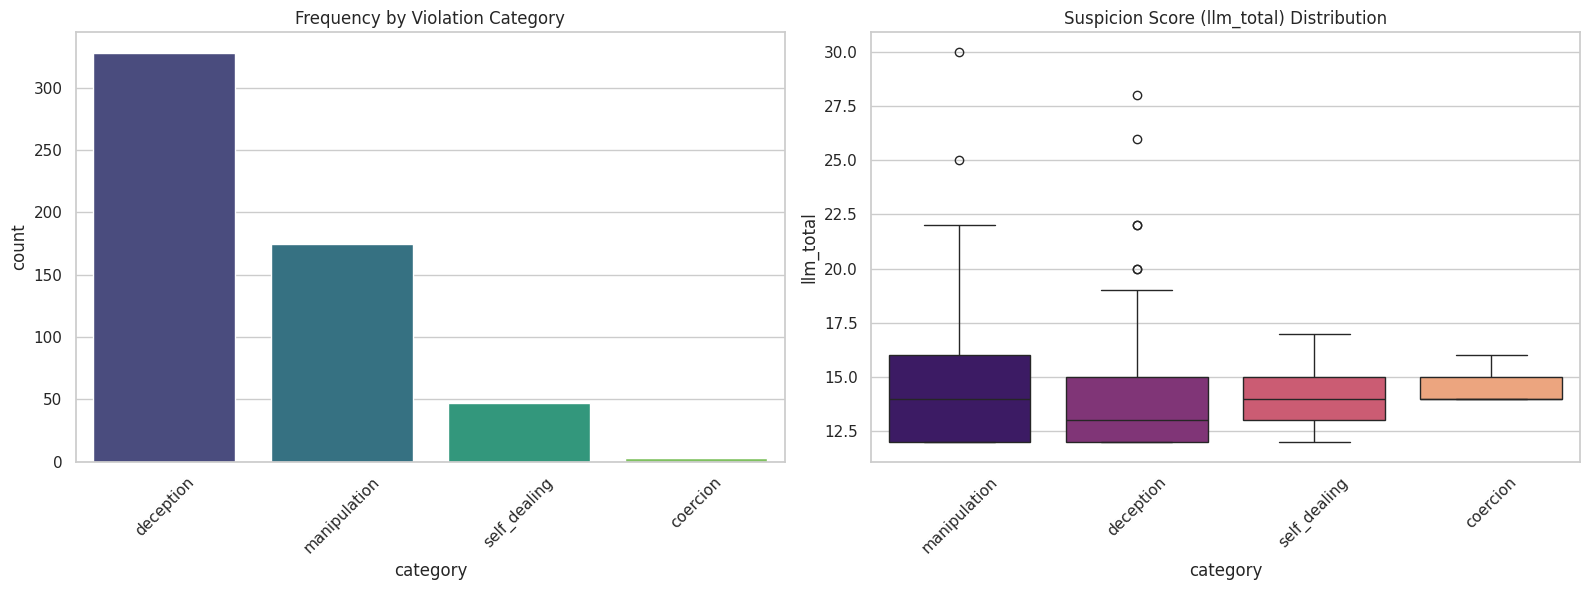

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
def generate_visualizations(df):
    """
    Input: list of dictionaries (the 673 flagged emails)
    Output: Saves four key plots as PNG files.
    """
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10})

    fig1, ax1 = plt.subplots(1, 2, figsize=(16, 6))

    sns.countplot(data=df, x='category', palette='viridis', ax=ax1[0],
                  order=df['category'].value_counts().index)
    ax1[0].set_title('Frequency by Violation Category')
    ax1[0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=df, x='category', y='llm_total', palette='magma', ax=ax1[1])
    ax1[1].set_title('Suspicion Score (llm_total) Distribution')
    ax1[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('enron_categories.png')

generate_visualizations(df)

/tmp/ipykernel_1951/3504659146.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='viridis', ax=ax1[0],
/tmp/ipykernel_1951/3504659146.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='llm_total', palette='magma', ax=ax1[1])


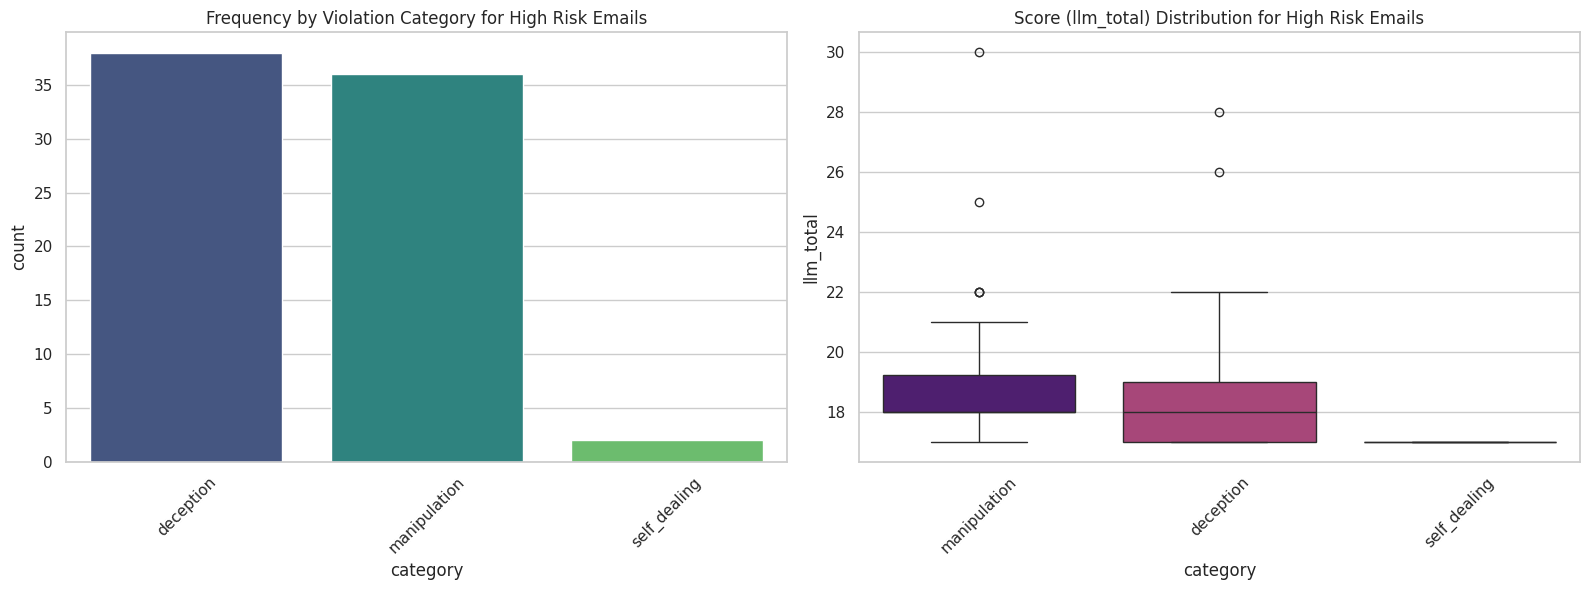

In [ ]:
def generate_visualizations_high(df):
    """
    Input: list of dictionaries (the 673 flagged emails)
    Output: Saves four key plots as PNG files.
    """
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10})

    fig1, ax1 = plt.subplots(1, 2, figsize=(16, 6))

    sns.countplot(data=df, x='category', palette='viridis', ax=ax1[0],
                  order=df['category'].value_counts().index)
    ax1[0].set_title('Frequency by Violation Category for High Risk Emails')
    ax1[0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=df, x='category', y='llm_total', palette='magma', ax=ax1[1])
    ax1[1].set_title('Score (llm_total) Distribution for High Risk Emails')
    ax1[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('enron_categories_high.png')

generate_visualizations_high(df[df.m_flaged == "HIGH"])

This second part of the analysis provides a breakdown of how different types of violations contribute to the overall Suspicion Score ($llm\_total$).

* Frequency by Violation Category (Bar Chart)
The left chart shows the volume of emails identified in each specific category.

* Deception is the dominant category: It has the highest frequency by a significant margin, suggesting that misleading information or fraudulent communication was the most common red flag in the dataset.

* Manipulation follows: While notably lower than deception, it remains a frequent tactic identified by the model.

* Self-dealing and Coercion: These appear much less frequently. The low count for "coercion" suggests that overt pressure was rarely captured or was not the primary driver of suspicious activity compared to covert deception.


##Suspicion Score Distribution (Box Plot)
The right chart shows the intensity (severity) of the suspicion scores across these same categories.

* Outliers in Manipulation and Deception: Both categories show extreme outliers reaching scores of 25.0 to 30.0. This indicates that while many emails in these categories are moderately suspicious, a select few are flagged with "extreme" suspicion.

* Manipulation Severity: Although "Manipulation" is less frequent than "Deception," its median score and upper whisker are slightly higher. This suggests that when manipulation occurs, it tends to be flagged with higher intensity than the typical deceptive email.

* Self-dealing Consistency: This category has a tighter interquartile range (IQR), meaning the suspicion level for self-dealing is more consistent and predictable, though it still contains one notable outlier at 26.0.

* Coercion and None: These have very low variance and no high-score outliers, indicating they contribute very little to the overall high-suspicion peaks seen in your weekly analysis.

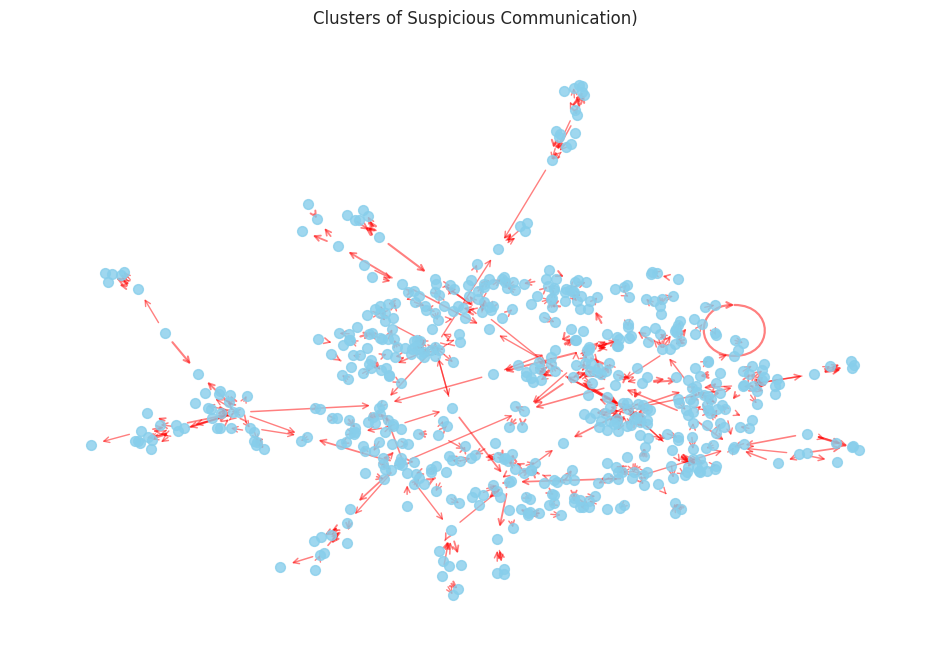

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def plot_risk_network(df, threshold=11):
    high_risk_df = df[df['llm_total'] > threshold]

    G = nx.from_pandas_edgelist(high_risk_df, 'from', 'to', edge_attr='llm_total', create_using=nx.DiGraph())

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=1.5) # k adjusts the distance between nodes

    nx.draw_networkx_nodes(G, pos, node_size=50, node_color='skyblue', alpha=0.8)

    edges = G.edges(data=True)
    weights = [d['llm_total']/12  for u, v, d in edges] 

    nx.draw_networkx_edges(G, pos, width=weights, edge_color='red', alpha=0.5, arrowstyle='->', arrowsize=10)



    nx.draw_networkx_labels(G, pos, {}, font_size=8)

    plt.title(f"Clusters of Suspicious Communication)")
    plt.axis('off')
    plt.show()

plot_risk_network(df)

# Netwrok of Emails:


--- TOP 5 SENDING HUBS ---
 ID          Name  Emails Sent
244 lorna.brennan          114
 14   alan.comnes           54
298 miyung.buster           50
110  ets <.nelson           41
433   w..cantrell           34

--- TOP 5 RECEIVING HUBS ---
 ID            Name  Emails Received
157   jeff.dasovich                8
331 richard.shapiro                8
408      susan.mara                7
416      tim.belden                7
148   james.steffes                6


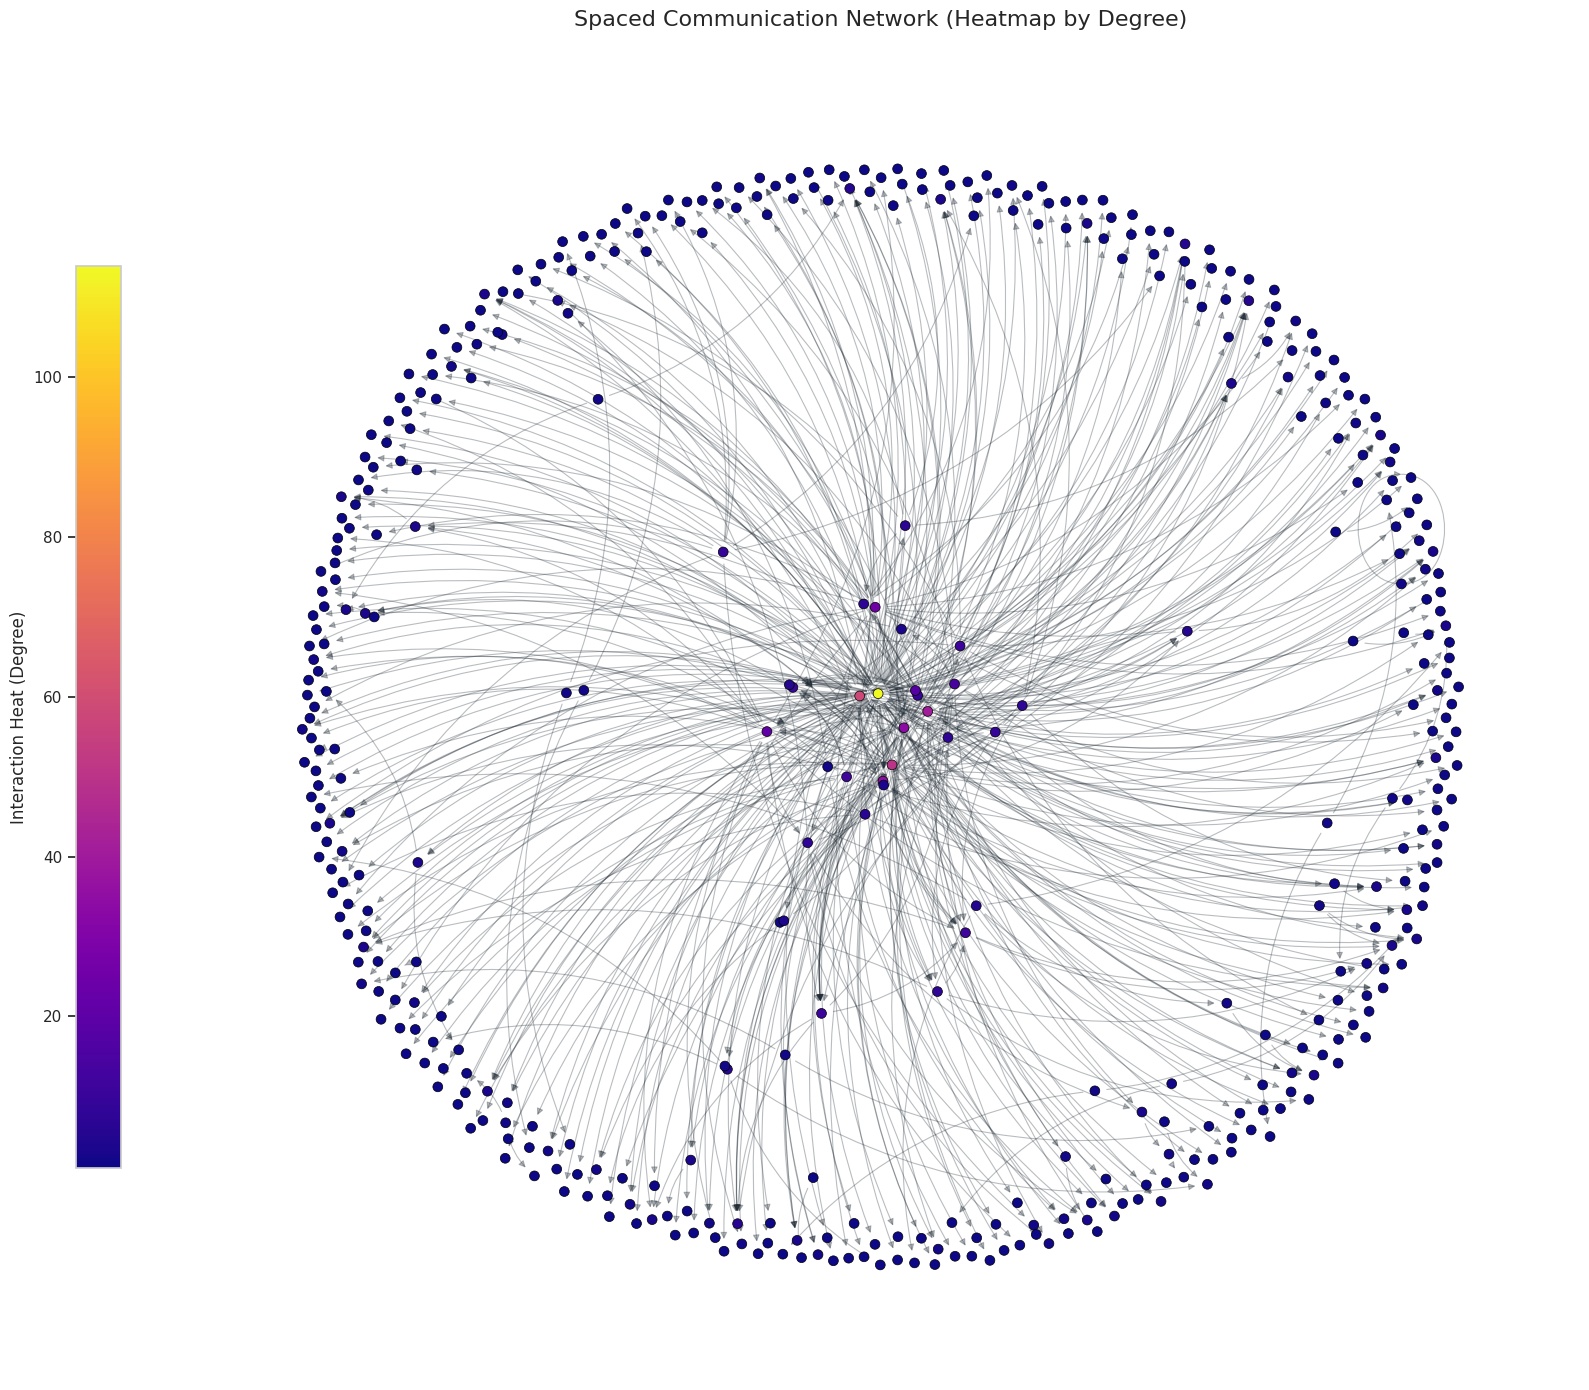

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import networkx as nx
import numpy as np
import pandas as pd

def plot_network(df):
    plt.figure(figsize=(16, 14))
    ax = plt.gca()

    G = nx.DiGraph()
    top_df = df.sort_values('llm_total', ascending=False).head(100).copy()

    all_senders = top_df['from'].str.split('@').str[0].unique()
    all_receivers = top_df['to'].str.replace('\n', ' ').str.replace(',', ' ').str.split().explode().str.split('@').str[0].dropna().unique()
    all_users_list = sorted(list(set(all_senders) | set(all_receivers)))

    user_to_id = {name: i for i, name in enumerate(all_users_list, 1)}
    id_to_user = {i: name for name, i in user_to_id.items()}

    for _, row in top_df.iterrows():
        u_name = str(row['from']).split('@')[0]
        u_id = user_to_id[u_name]
        v_list = str(row['to']).replace('\n', ' ').replace(',', ' ').split()
        for v_raw in v_list:
            if '@' in v_raw:
                v_name = v_raw.split('@')[0]
                if v_name in user_to_id:
                    v_id = user_to_id[v_name]
                    G.add_edge(u_id, v_id, weight=row['llm_total'])


    pos = nx.spring_layout(G, k=.1, iterations=100, seed=42)


    degrees = dict(G.degree())
    node_indices = list(G.nodes())
    node_colors = [degrees[n] for n in node_indices]

    norm = colors.Normalize(vmin=min(node_colors), vmax=max(node_colors))
    cmap = cm.plasma

    nx.draw_networkx_edges(G, pos, width=0.8, edge_color='#1a252f',
                          arrows=True, arrowsize=10, alpha=0.3,
                          connectionstyle='arc3,rad=0.2')

    nx.draw_networkx_nodes(G, pos,
                          node_size=50,
                          node_color=node_colors,
                          cmap=cmap,
                          edgecolors='black', linewidths=0.5)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, location='left', fraction=0.03, pad=0.04)
    cbar.set_label('Interaction Heat (Degree)', fontsize=12)

    plt.title('Spaced Communication Network (Heatmap by Degree)', fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('enron_network_spaced.png', dpi=300)

    out_map = dict(G.out_degree())
    in_map = dict(G.in_degree())

    def get_hub_table(d_dict, label):
        sorted_d = sorted(d_dict.items(), key=lambda x: x[1], reverse=True)[:5]
        return pd.DataFrame([{'ID': n, 'Name': id_to_user[n], label: c} for n, c in sorted_d])

    print("\n--- TOP 5 SENDING HUBS ---")
    print(get_hub_table(out_map, 'Emails Sent').to_string(index=False))

    print("\n--- TOP 5 RECEIVING HUBS ---")
    print(get_hub_table(in_map, 'Emails Received').to_string(index=False))

plot_network(df)

/tmp/ipykernel_1951/4709285.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_clusters) # Distinct colors for clusters


Success! Detected 23 distinct communication clusters.

--- TOP 5 SENDING HUBS ---
 ID          Name  Emails Sent
197 lorna.brennan          103
242 miyung.buster           50
 83  ets <.nelson           41
353   w..cantrell           34
  4   alan.comnes           31

--- TOP 5 RECEIVING HUBS ---
 ID            Name  Emails Received
123   jeff.dasovich                7
333      susan.mara                7
341      tim.belden                7
271 richard.shapiro                6
 22   bill.williams                5


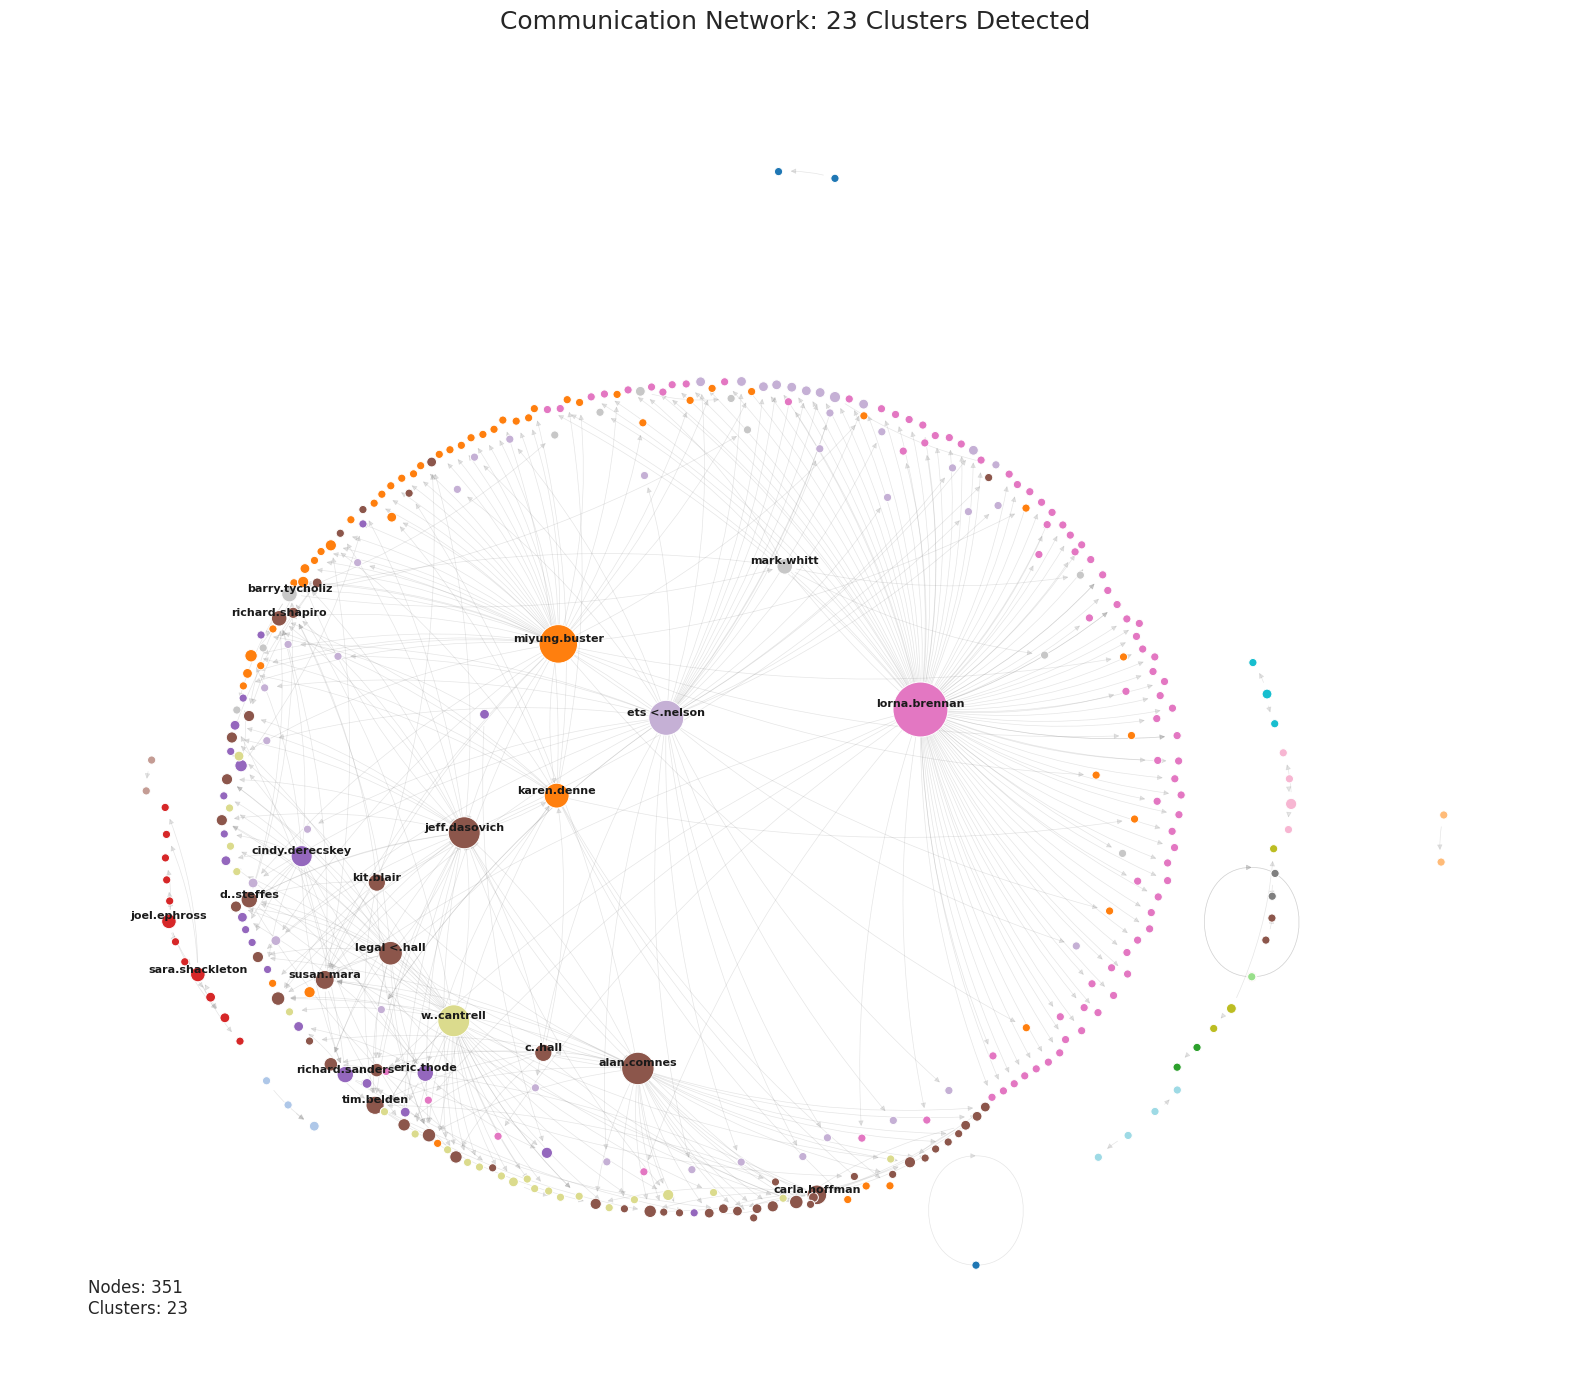

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as colors
from community import community_louvain 

def plot_network_clusters(df):
    plt.figure(figsize=(16, 14))
    ax = plt.gca()

    G_dir = nx.DiGraph()
    top_df = df.sort_values('llm_total', ascending=False).head(150).copy()

    all_senders = top_df['from'].str.split('@').str[0].unique()
    all_receivers = top_df['to'].str.replace('\n', ' ').str.replace(',', ' ').str.split().explode().str.split('@').str[0].dropna().unique()
    all_users_list = sorted(list(set(all_senders) | set(all_receivers)))
    user_to_id = {name: i for i, name in enumerate(all_users_list, 1)}
    id_to_user = {i: name for name, i in user_to_id.items()}

    for _, row in top_df.iterrows():
        u_name = str(row['from']).split('@')[0]
        u_id = user_to_id[u_name]
        v_list = str(row['to']).replace('\n', ' ').replace(',', ' ').split()
        for v_raw in v_list:
            if '@' in v_raw:
                v_name = v_raw.split('@')[0]
                if v_name in user_to_id:
                    v_id = user_to_id[v_name]
                    G_dir.add_edge(u_id, v_id, weight=row['llm_total'])


    G_undir = G_dir.to_undirected()
    partition = community_louvain.best_partition(G_undir)


    seed_pos = nx.spectral_layout(G_dir, weight='weight')

    pos = nx.spring_layout(G_dir, pos=seed_pos, k=1.5, iterations=50)


    cluster_ids = list(partition.values())
    num_clusters = len(set(cluster_ids))
    cmap = cm.get_cmap('tab20', num_clusters) 

    nx.draw_networkx_edges(G_dir, pos, width=0.5, edge_color='gray',
                          arrows=True, arrowsize=8, alpha=0.2,
                          connectionstyle='arc3,rad=0.1')

    nodes = nx.draw_networkx_nodes(G_dir, pos,
                                  node_size=[(G_dir.degree(n) * 15) + 20 for n in G_dir.nodes()],
                                  node_color=cluster_ids,
                                  cmap=cmap,
                                  edgecolors='white', linewidths=0.7)

    # 5. Labels for Hubs (only label nodes with high degree to avoid clutter)
    high_degree_nodes = [n for n, d in G_dir.degree() if d > 5]
    labels = {n: id_to_user[n] for n in high_degree_nodes}
    nx.draw_networkx_labels(G_dir, pos, labels=labels, font_size=8,
                           font_weight='bold', verticalalignment='bottom')

    plt.title(f'Communication Network: {num_clusters} Clusters Detected', fontsize=18, pad=20)
    plt.axis('off')

    plt.annotate(f"Nodes: {G_dir.number_of_nodes()}\nClusters: {num_clusters}",
                 xy=(0.05, 0.05), xycoords='axes fraction', fontsize=12,
                 bbox=dict(boxstyle="round", fc="w", alpha=0.5))

    plt.tight_layout()
    plt.savefig('network_clusters.png', dpi=300)
    print(f"Success! Detected {num_clusters} distinct communication clusters.")

    out_map = dict(G_dir.out_degree())
    in_map = dict(G_dir.in_degree())

    def get_hub_table(d_dict, label):
        sorted_d = sorted(d_dict.items(), key=lambda x: x[1], reverse=True)[:5]
        return pd.DataFrame([{'ID': n, 'Name': id_to_user[n], label: c} for n, c in sorted_d])

    print("\n--- TOP 5 SENDING HUBS ---")
    print(get_hub_table(out_map, 'Emails Sent').to_string(index=False))

    print("\n--- TOP 5 RECEIVING HUBS ---")
    print(get_hub_table(in_map, 'Emails Received').to_string(index=False))

plot_network_clusters(df[df.m_flaged == "HIGH"])

This graph is a Communication Cluster Map, generated by applying community detection (the Louvain algorithm) to a set of interaction data (likely email logs).

Instead of showing just who talks to whom, it organizes the network into "communities"—groups of users who interact with each other significantly more than they do with the rest of the organization.

Here is a breakdown of what the graph represents:

1. What the visual elements mean:
The Clusters (Colors): Each color represents a distinct "communication silo" or functional group. These represent groups of people who are working closely together on shared projects, topics, or workflows.

The Nodes (Circles): Each circle represents an individual.

Size: The size of the node indicates its Degree Centrality. Larger nodes are "hubs"—people who are highly active or act as central connectors within their cluster.

The Edges (Arrows): These represent the flow of information.

Density: The number of lines between nodes shows the frequency or volume of communication.

Curvature: The arcs help reduce visual "hairball" overlap, making it easier to see the direction of the interaction.

2. What this graph reveals (The "So What"):
Organizational Structure: It allows you to visualize how an organization actually functions versus how it is organized on an official org chart. You can often spot cross-departmental collaboration (where lines bridge different color clusters).

Key Influencers: By looking for large nodes at the center of a cluster, you identify the "Gatekeepers" or "Subject Matter Experts" whom the group relies on most heavily for information.

Bottlenecks: If you see a very small node that acts as the only connection between two large, distinct color clusters, that person is a critical communication bridge—and a potential point of failure if they are overloaded.

Disconnected Entities: Isolated nodes or small satellite groups can reveal teams that are working in isolation from the rest of the network.

3. Summary for Stakeholders
"This map visualizes the informal social and operational structure of the organization. By grouping users into color-coded clusters, we can identify which teams are collaborating most closely. The size of the nodes highlights the most influential members of those teams, helping us understand who the primary drivers of information flow are within the business."

/tmp/ipykernel_1951/256262856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["from_"] = df["from"].map(lambda x: x.split("@")[0])
/tmp/ipykernel_1951/256262856.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["to_"] = df["to"].map(lambda x: x.split("@")[0])


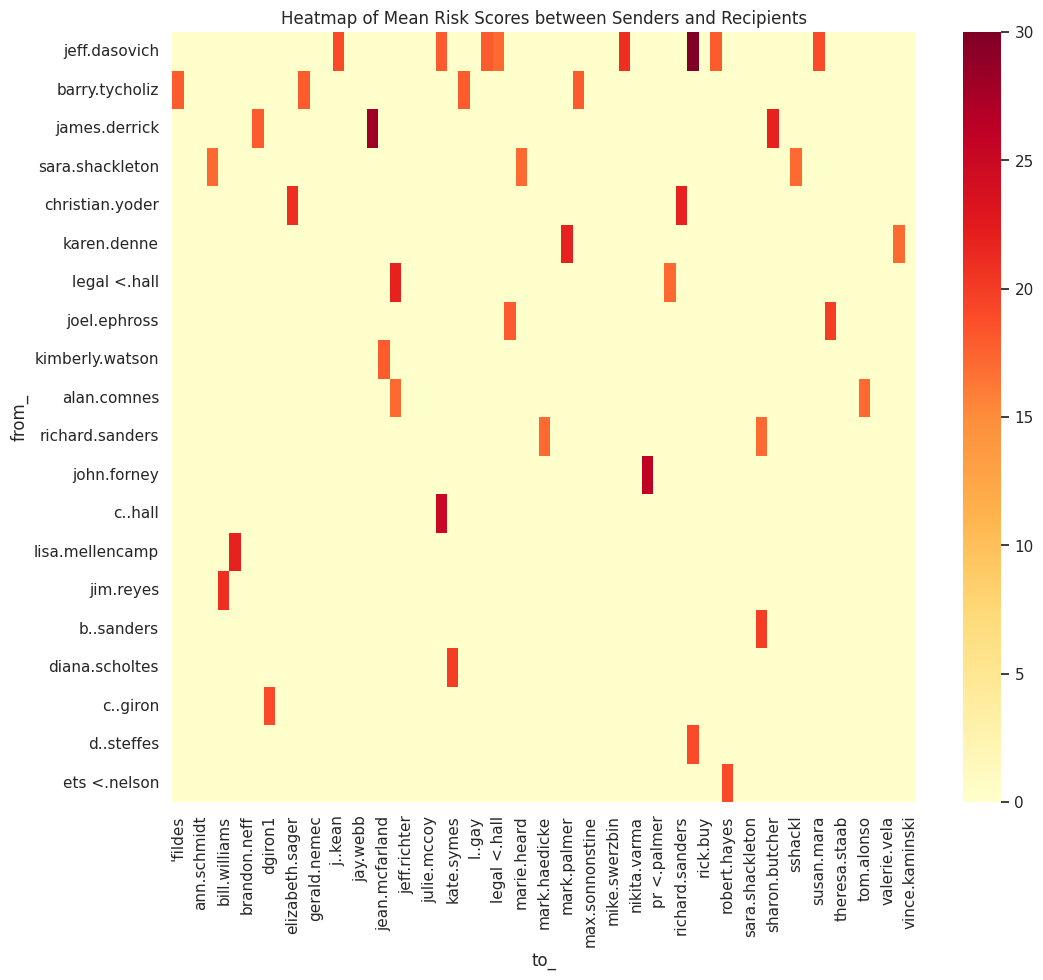

In [ ]:
import seaborn as sns

def plot_risk_heatmap(df):
    df["from_"] = df["from"].map(lambda x: x.split("@")[0])
    df["to_"] = df["to"].map(lambda x: x.split("@")[0])
    pivot_table = df.groupby(['from_', 'to_'])['llm_total'].mean().unstack().fillna(0)

    top_senders = df.groupby('from_')['llm_total'].sum().nlargest(20).index
    pivot_table = pivot_table.loc[top_senders]

    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot_table, annot=False, cmap='YlOrRd')
    plt.title("Heatmap of Mean Risk Scores between Senders and Recipients")
    plt.show()

plot_risk_heatmap(df[df.m_flaged == "HIGH"])

# Scored Email:
all LLM-scored emails with per-question scores: enron_scored_emails.csv

In [ ]:
import pandas as pd
df = pd.read_csv('data/enron_scored_emails.csv')
df.head()

/tmp/ipykernel_1818/938015086.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/enron_scored_emails.csv')


,id,date,from,subject,kw_total,kw_cats,kw_deception,kw_coercion,kw_self_dealing,kw_manipulation,...,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10
0,175509,2001-07-10T00:19:00.000Z,jeff.dasovich@enron.com,Re: Transcript of a bizarre and unusual teleph...,1,1,0,0,0,1,...,5.0,5.0,3.0,3.0,0.0,0.0,0.0,5.0,4.0,5.0
1,187112,2001-03-21T14:11:35.000Z,james.derrick@enron.com,FW: URGENT RESPONSE REQUIRED,1,1,1,0,0,0,...,4.0,5.0,4.0,4.0,0.0,5.0,1.0,0.0,0.0,5.0
2,227685,2000-12-07T21:12:00.000Z,john.forney@enron.com,Out of Market Enpower procedures,2,2,1,0,0,1,...,5.0,4.0,5.0,0.0,0.0,1.0,0.0,3.0,3.0,5.0
3,242195,2002-01-11T01:33:57.000Z,charlesnujoma@37.com,urgent and confidential,1,1,1,0,0,0,...,5.0,4.0,3.0,4.0,0.0,5.0,0.0,0.0,0.0,5.0
4,43338,2001-07-09T18:29:12.000Z,c..hall@enron.com,Transcript of a bizarre and unusual telephone ...,1,1,0,0,0,1,...,4.0,4.0,0.0,3.0,0.0,0.0,0.0,5.0,4.0,5.0


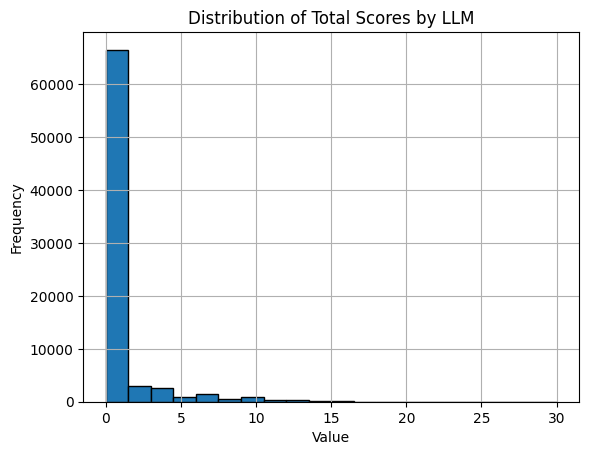

In [ ]:
import matplotlib.pyplot as plt

df.llm_total.hist(bins=20, edgecolor='black')
plt.title('Distribution of Total Scores by LLM')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import numpy as np
quantiles = np.linspace(0.1, 1.0, 10)
decile_levels = [.8, .9, .95, .99, .995]

stats = df[["llm_total", 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10']].describe(percentiles=decile_levels)
display(stats.round(2))

,llm_total,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10
count,76562.00,61903.00,61903.00,61903.00,61903.00,61903.00,61903.00,61903.00,61903.00,61903.00,61903.00
mean,0.75,0.20,0.07,0.20,0.04,0.01,0.09,0.01,0.09,0.05,0.17
std,2.18,0.68,0.39,0.66,0.27,0.11,0.45,0.16,0.43,0.34,0.63
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
80%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
90%,2.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
95%,5.00,2.00,0.00,2.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00
99%,11.00,4.00,2.00,3.00,1.00,0.00,3.00,0.00,3.00,2.00,3.00
99.5%,13.00,4.00,3.00,4.00,2.00,0.00,4.00,1.00,3.00,3.00,4.00


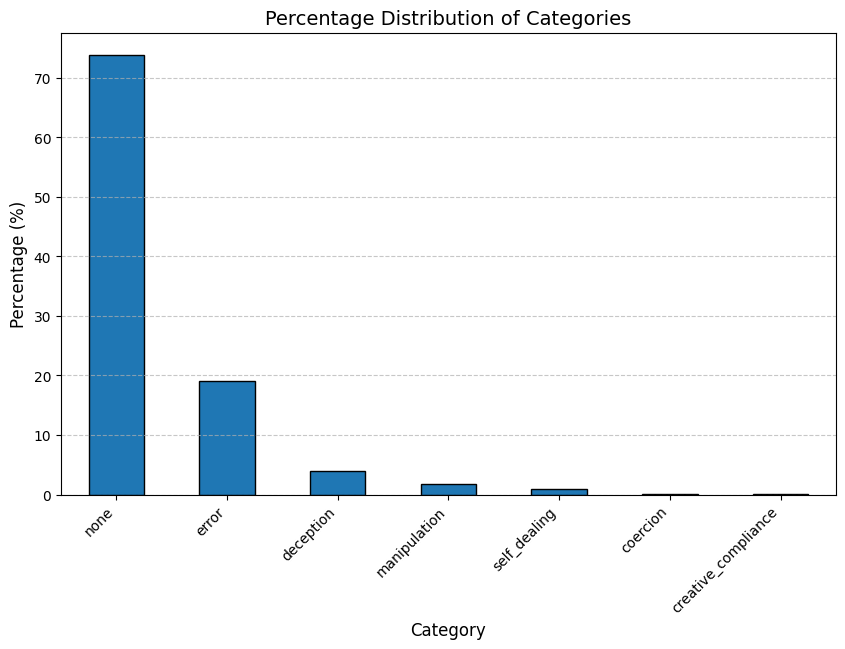

In [ ]:
import matplotlib.pyplot as plt


exploded_categories = df['category'].explode()

category_percentages = exploded_categories.value_counts(normalize=True) * 100

category_percentages.plot(kind='bar', figsize=(10, 6), edgecolor='black')

plt.title('Percentage Distribution of Categories', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

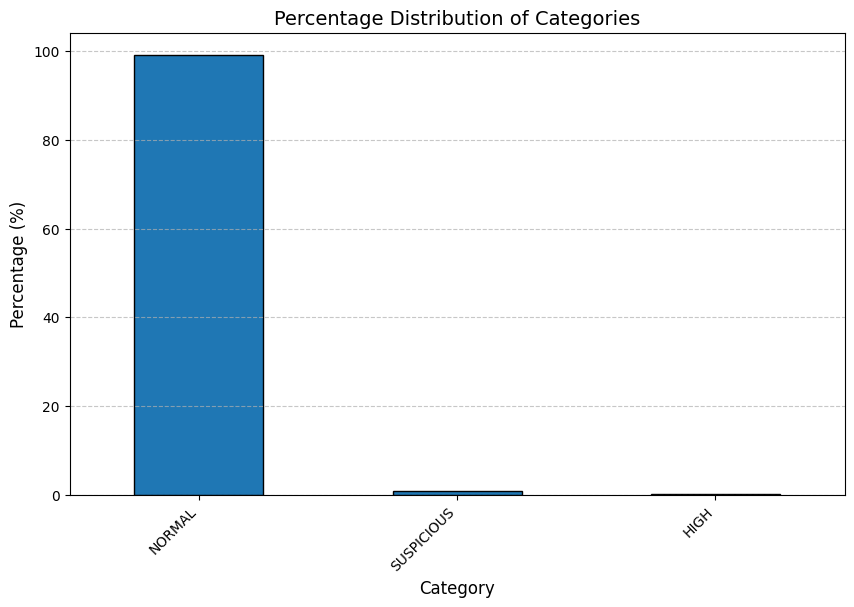

,proportion
flag,
NORMAL,99.154933
SUSPICIOUS,0.762780
HIGH,0.082286


In [ ]:
import matplotlib.pyplot as plt

exploded_categories = df['flag'].explode()

category_percentages = exploded_categories.value_counts(normalize=True) * 100

category_percentages.plot(kind='bar', figsize=(10, 6), edgecolor='black')

plt.title('Percentage Distribution of Categories', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
display(category_percentages)